<a href="https://colab.research.google.com/github/BlackSwan96/index.html/blob/main/My06CodeChiSquare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goodness of Fit and Contingency Tables


In [ ]:
def GoodnessFit(Observed,BinNames,Pexpect):
  import numpy as np;   import matplotlib.pyplot as plt;   import pandas as pd
  from scipy.stats import chisquare;  from scipy.stats import chi2

  O = np.array(Observed);   P_exp = np.array(Pexpect);    n = len(O)
  total = np.sum(O);
  print("Total Observed = {:d} + {:d} + ... {:d} = {:d}"
        .format(O[0],O[1],O[n-1], total))
  E = total*P_exp;
  print("Expected frequencies = E = total*P_exp ={:d}*[{:.3f},{:.3f},....,{:.3f}]="
           .format(total,P_exp[0],P_exp[1],P_exp[n-1]))
  print('     [{:.3f},{:.3f},....,{:.3f}]'.format(E[0],E[1],E[n-1]))
  print('Residuals = (Observed - Expected)/sqrt(Expected) = ')
  print('=({:d}-{:.2f})/sqrt({:.2f}), ... , ({:d}-{:.2f})/sqrt({:.2f})\n'
  .format(O[0],E[0],E[0],O[n-1],E[n-1],E[n-1]))
  R = (O-E)/np.sqrt(E);   R2 = R**2;

  Frame = pd.DataFrame({'Observed': O, 'Expected P': P_exp, 'Expected': E,
                        'Residuals': R, 'Residuals**2': R2})
  Frame.index = BinNames;
  pd.set_option("display.precision", 4); print(Frame,'\n')

  df = len(O)-1; print("df = len(O)-1 ={:d}-1 = {:d}".format(len(O),df))
  X2 = np.sum(R2);

  print('Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = ')
  print('=({:d}-{:.2f})**2/{:.2f} +  ... + ({:d}-{:.2f})**2/{:.2f} = {:.3f}'
  .format(O[0],E[0],E[0],O[n-1],E[n-1],E[n-1],X2))

  pval = 1 - chi2.cdf(X2,df)
  print('p-value = 1 - chi2.cdf(X2,df) = ', pval, '\n')

  (X2, pval) = chisquare(f_obs=O,f_exp=E)
  print("From chisquare function: X2 = ", round(X2,3), '  pval = ', pval)

  x = np.arange(0, X2+10, 0.001)  #x-axis ranges from 0 to 20 with .001 steps
  P1 = plt.plot(x, chi2.pdf(x, df=df)) #plot Chi-square
  xR=np.arange(X2,X2+10,0.001)
  plt.fill_between(xR,chi2.pdf(xR, df=df),color='r') # filling for p-value
  plt.show(P1)

  Frame[['Observed','Expected']].plot(kind='bar')   # barplot for observed data

Total Observed = 25 + 41 + ... 68 = 225
Expected frequencies = E = total*P_exp =225*[0.100,0.200,....,0.300]=
     [22.500,45.000,....,67.500]
Residuals = (Observed - Expected)/sqrt(Expected) = 
=(25-22.50)/sqrt(22.50), ... , (68-67.50)/sqrt(67.50)

         Observed  Expected P  Expected  Residuals  Residuals**2
Small          25         0.1      22.5     0.5270        0.2778
Medium         41         0.2      45.0    -0.5963        0.3556
Large          91         0.4      90.0     0.1054        0.0111
X-Large        68         0.3      67.5     0.0609        0.0037 

df = len(O)-1 =4-1 = 3
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(25-22.50)**2/22.50 +  ... + (68-67.50)**2/67.50 = 0.648
p-value = 1 - chi2.cdf(X2,df) =  0.8853267818237286 

From chisquare function: X2 =  0.648   pval =  0.8853267818237286


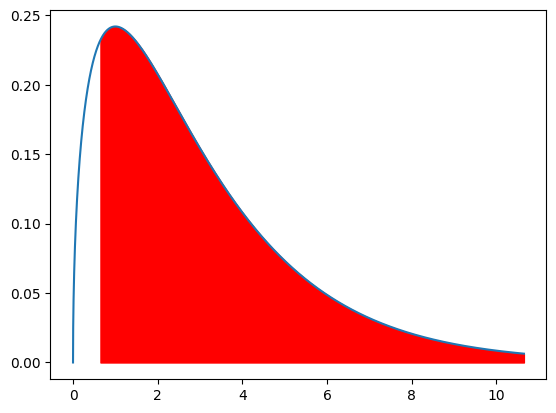

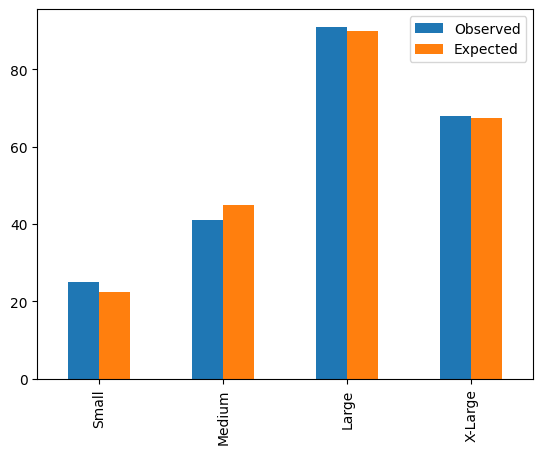

In [ ]:
GoodnessFit(Observed=[25, 41, 91, 68],
            BinNames=["Small","Medium","Large","X-Large"],
            Pexpect=[0.1, 0.2, 0.4, 0.3])

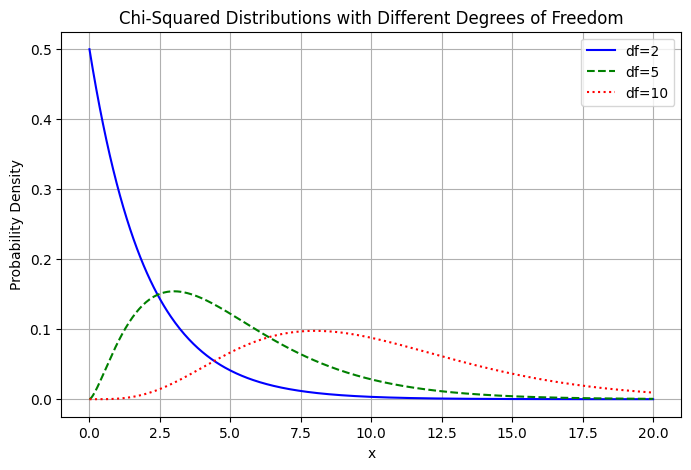

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Parameters for the chi-squared distributions
df_values = [2, 5, 10]  # Degrees of freedom
x = np.linspace(0, 20, 500)  # x-values for the plots

# Line styles and colors for the distributions
linestyles = ['-', '--', ':']
colors = ['blue', 'green', 'red']

# Plotting the chi-squared distributions
plt.figure(figsize=(8, 5))

for df, ls, color in zip(df_values, linestyles, colors):
    y = chi2.pdf(x, df)  # Compute the PDF of the chi-squared distribution
    plt.plot(x, y, linestyle=ls, color=color, label=f"df={df}")

# Add title, labels, legend, and grid
plt.title("Chi-Squared Distributions with Different Degrees of Freedom")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

Total Observed = 99 + 72 + ... 92 = 535
Expected frequencies = E = total*P_exp =535*[0.143,0.143,....,0.143]=
     [76.429,76.429,....,76.429]
Residuals = (Observed - Expected)/sqrt(Expected) = 
=(99-76.43)/sqrt(76.43), ... , (92-76.43)/sqrt(76.43)

     Observed  Expected P  Expected  Residuals  Residuals**2
Sun        99      0.1429   76.4286     2.5819        6.6660
Mon        72      0.1429   76.4286    -0.5066        0.2566
Tue        69      0.1429   76.4286    -0.8497        0.7220
Wed        62      0.1429   76.4286    -1.6504        2.7239
Thr        67      0.1429   76.4286    -1.0785        1.1632
Fri        74      0.1429   76.4286    -0.2778        0.0772
Sat        92      0.1429   76.4286     1.7812        3.1725 

df = len(O)-1 =7-1 = 6
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(99-76.43)**2/76.43 +  ... + (92-76.43)**2/76.43 = 14.781
p-value = 1 - chi2.cdf(X2,df) =  0.022027570437209598 

From chisquare function: X2 =  14.781   pval =  0.02202757043720961

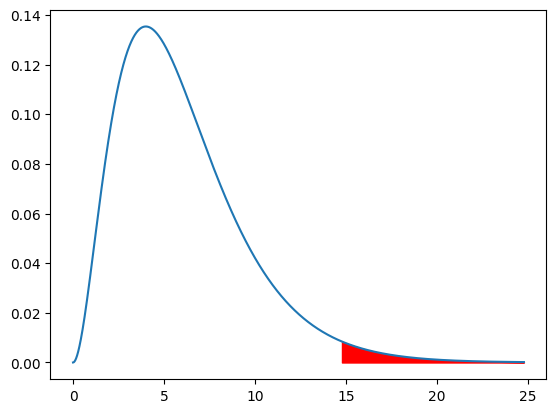

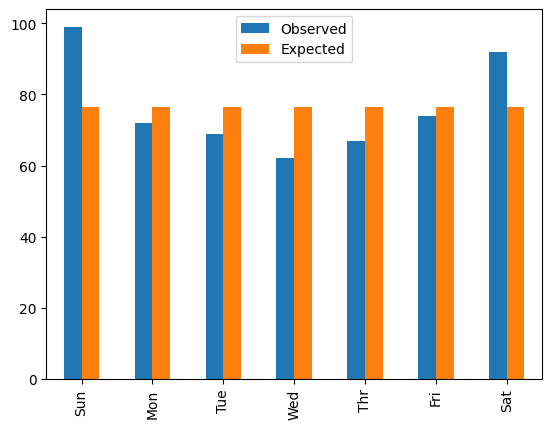

In [ ]:
GoodnessFit(Observed=[99,72,69,62,67,74,92],
            BinNames=['Sun','Mon','Tue','Wed','Thr','Fri','Sat'],
            Pexpect=[1/7,1/7,1/7,1/7,1/7,1/7,1/7])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

url="https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv"
mydata = pd.read_csv(url)   # save as mydata file
counts = mydata['substance'].value_counts(); counts

substance
alcohol    177
cocaine    152
heroin     124
Name: count, dtype: int64

Total Observed = 177 + 152 + ... 124 = 453
Expected frequencies = E = total*P_exp =453*[0.333,0.333,....,0.333]=
     [151.000,151.000,....,151.000]
Residuals = (Observed - Expected)/sqrt(Expected) = 
=(177-151.00)/sqrt(151.00), ... , (124-151.00)/sqrt(151.00)

         Observed  Expected P  Expected  Residuals  Residuals**2
alcohol       177      0.3333     151.0     2.1158        4.4768
cocaine       152      0.3333     151.0     0.0814        0.0066
heroin        124      0.3333     151.0    -2.1972        4.8278 

df = len(O)-1 =3-1 = 2
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(177-151.00)**2/151.00 +  ... + (124-151.00)**2/151.00 = 9.311
p-value = 1 - chi2.cdf(X2,df) =  0.009507929549892102 

From chisquare function: X2 =  9.311   pval =  0.009507929549892056


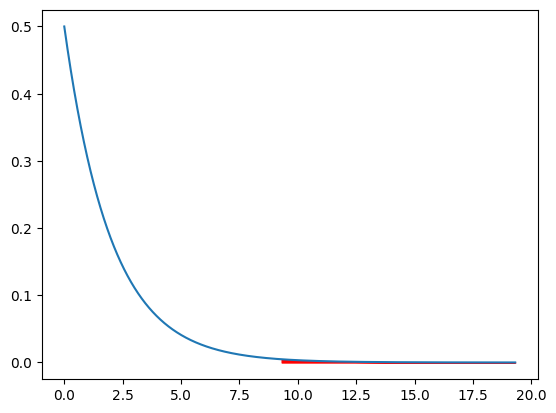

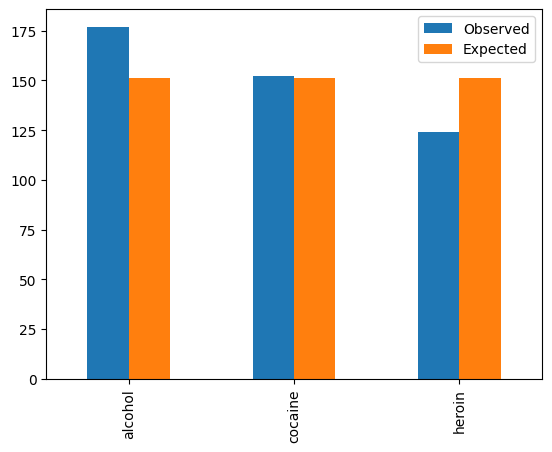

In [ ]:
GoodnessFit(Observed=[177,152,124],
            BinNames=['alcohol','cocaine','heroin'],
            Pexpect=[1/3,1/3,1/3])

Total Observed = 58 + 69 + ... 29 = 289
Expected frequencies = E = total*P_exp =289*[0.230,0.230,....,0.120]=
     [66.470,66.470,....,34.680]
Residuals = (Observed - Expected)/sqrt(Expected) = 
=(58-66.47)/sqrt(66.47), ... , (29-34.68)/sqrt(34.68)

        Observed  Expected P  Expected  Residuals  Residuals**2
Blue          58        0.23     66.47    -1.0389        1.0793
Orange        69        0.23     66.47     0.3103        0.0963
Green         50        0.15     43.35     1.0100        1.0201
Yellow        42        0.15     43.35    -0.2050        0.0420
Red           41        0.12     34.68     1.0732        1.1517
Brown         29        0.12     34.68    -0.9645        0.9303 

df = len(O)-1 =6-1 = 5
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(58-66.47)**2/66.47 +  ... + (29-34.68)**2/34.68 = 4.320
p-value = 1 - chi2.cdf(X2,df) =  0.5043501118366657 

From chisquare function: X2 =  4.32   pval =  0.5043501118366656


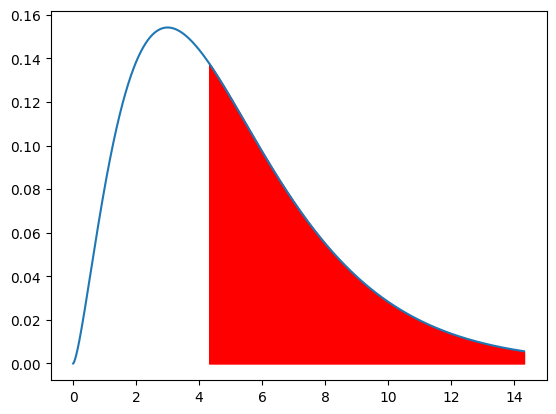

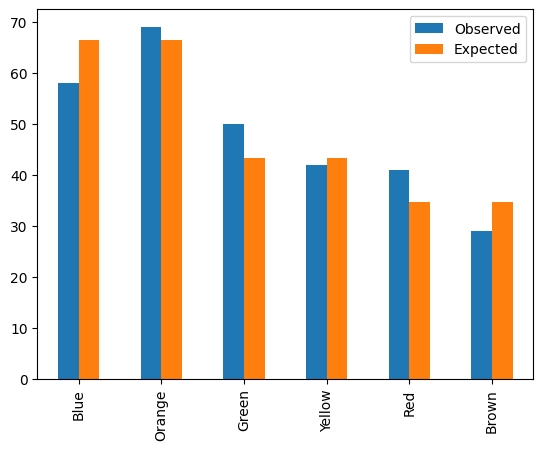

In [ ]:
GoodnessFit(Observed=[58, 69, 50, 42, 41, 29],
            BinNames=["Blue","Orange","Green","Yellow","Red","Brown"],
            Pexpect=[0.23,0.23,0.15,0.15,0.12,0.12])

In [ ]:
import numpy as np
nv = np.arange(1,10)
P_exp = np.array(np.log10(nv+1)-np.log10(nv)); P_exp
# log10(2)-log10(1), log10(3)-log10(2), log10(4)-log10(3)

array([0.30103   , 0.17609126, 0.12493874, 0.09691001, 0.07918125,
       0.06694679, 0.05799195, 0.05115252, 0.04575749])

Total Observed = 1110 + 601 + ... 156 = 3542
Expected frequencies = E = total*P_exp =3542*[0.301,0.176,....,0.046]=
     [1066.248,623.715,....,162.073]
Residuals = (Observed - Expected)/sqrt(Expected) = 
=(1110-1066.25)/sqrt(1066.25), ... , (156-162.07)/sqrt(162.07)

   Observed  Expected P   Expected  Residuals  Residuals**2
1      1110      0.3010  1066.2482     1.3399        1.7953
2       601      0.1761   623.7152    -0.9095        0.8273
3       462      0.1249   442.5330     0.9254        0.8564
4       345      0.0969   343.2553     0.0942        0.0089
5       260      0.0792   280.4600    -1.2217        1.4926
6       223      0.0669   237.1255    -0.9173        0.8415
7       205      0.0580   205.4075    -0.0284        0.0008
8       180      0.0512   181.1822    -0.0878        0.0077
9       156      0.0458   162.0730    -0.4770        0.2276 

df = len(O)-1 =9-1 = 8
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(1110-1066.25)**2/1066.25 +  ... + (156-162.07)**2

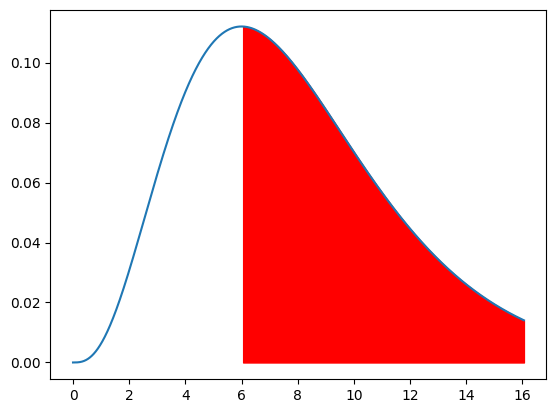

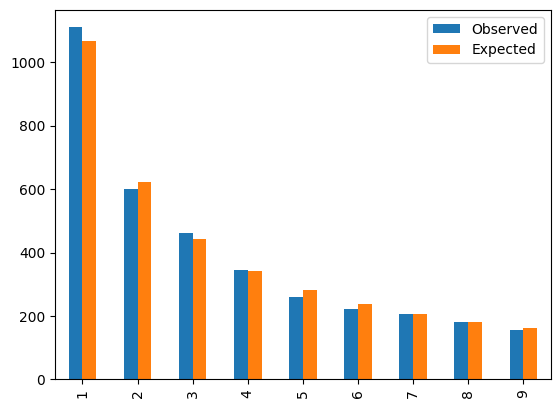

In [ ]:
GoodnessFit(Observed=[1110,601,462,345,260,223,205,180,156],
            BinNames=["1","2","3","4","5","6","7","8","9"],
            Pexpect=P_exp)

In [ ]:
def ChiSqIndependence(Observed):
  import numpy as np;   import matplotlib.pyplot as plt;
  import pandas as pd;  from scipy.stats import chi2_contingency;
  from scipy.stats import chi2

  O = Observed;  nr = Observed.shape[0];  nc = Observed.shape[1];

  Om = pd.DataFrame.copy(O)   # creating margins
  Om['Sum'] = O.sum(axis=1)
  rowsum = O.sum(axis=1)
  colsum = O.sum(axis=0)
  Om.loc[len(Om.index)] = colsum.tolist() + [O.sum().sum()]
  print(Om)
  print('nr, nc = ', nr,nc)

  chi_val, p_val, dof, E =  chi2_contingency(O,correction=False)

  print('Expected in cell E00 = {:d}*{:d}/{:d} = {:.3f}'
         .format(rowsum[0],colsum[0],O.sum().sum(),E[0,0]))
  print('Expected in cell E01 = {:d}*{:d}/{:d} = {:.3f}'
         .format(rowsum[0],colsum[1],O.sum().sum(),E[0,1]))
  print('Expected in the last cell = {:d}*{:d}/{:d} = {:.3f}'
         .format(rowsum[nr-1],colsum[nc-1],O.sum().sum(),E[nr-1,nc-1]))

  print('Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = ')
  print('=({:d}-{:.2f})**2/{:.2f} +  ... + ({:d}-{:.2f})**2/{:.2f} = {:.3f}'
  .format(O.iloc[0,0],E[0,0],E[0,0],O.iloc[nr-1,nc-1], \
          E[nr-1,nc-1],E[nr-1,nc-1],chi_val))

  print('degree of freedom = df =(nr-1)(nc-1)= ({:d}-1)({:d}-1) = {:d}'
          .format(nr,nc,dof))
  pval = 1 - chi2.cdf(chi_val,df=dof)
  print('pval = 1 - chi2.cdf(X2,df) = ',pval,'\n')

  print("From built in chisquare : X2 = ", round(chi_val,3), '  pval = ', pval)
  print("Expected: ")
  print(E)

  from scipy.stats import chi2
  x = np.arange(0, chi_val+10, 0.001)
  P1 = plt.plot(x, chi2.pdf(x, df=dof))
  xR=np.arange(chi_val,chi_val+10,0.001)
  plt.fill_between(xR,chi2.pdf(xR, df=dof),color='r') # filling for p-value
  plt.show(P1)
  O.plot.bar(stacked=True)

             Placebo  LowDose  HighDose  Sum
Infected          10       28        31   69
NotInfected       40       60        64  164
2                 50       88        95  233
nr, nc =  2 3
Expected in cell E00 = 69*50/233 = 14.807
Expected in cell E01 = 69*88/233 = 26.060
Expected in the last cell = 164*95/233 = 66.867
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(10-14.81)**2/14.81 +  ... + (64-66.87)**2/66.87 = 2.837
degree of freedom = df =(nr-1)(nc-1)= (2-1)(3-1) = 2
pval = 1 - chi2.cdf(X2,df) =  0.24204221633323164 

From built in chisquare : X2 =  2.837   pval =  0.24204221633323164
Expected: 
[[14.80686695 26.06008584 28.13304721]
 [35.19313305 61.93991416 66.86695279]]


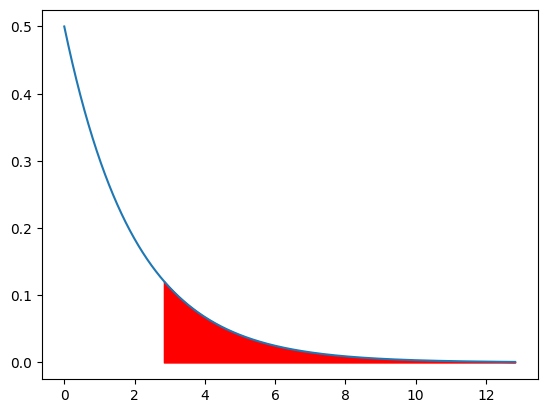

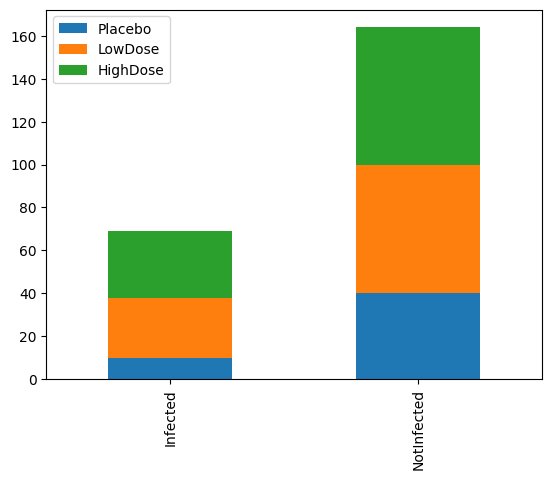

In [ ]:
import pandas as pd
O = pd.DataFrame({'Placebo':[10,40], 'LowDose':[28,60], 'HighDose':[31,64]},
                 index= ['Infected','NotInfected'])
ChiSqIndependence(O)

In [ ]:
O.iloc[0,:]/O.sum(axis=0)

Placebo     0.200000
LowDose     0.318182
HighDose    0.326316
dtype: float64

              Support  Oppose   Sum
Republicans       250     489   739
Democrats         431     220   651
Independents      320     298   618
3                1001    1007  2008
nr, nc =  3 2
Expected in cell E00 = 739*1001/2008 = 368.396
Expected in cell E01 = 739*1007/2008 = 370.604
Expected in the last cell = 618*1007/2008 = 309.923
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(250-368.40)**2/368.40 +  ... + (298-309.92)**2/309.92 = 146.450
degree of freedom = df =(nr-1)(nc-1)= (3-1)(2-1) = 2
pval = 1 - chi2.cdf(X2,df) =  0.0 

From built in chisquare : X2 =  146.45   pval =  0.0
Expected: 
[[368.39591633 370.60408367]
 [324.52739044 326.47260956]
 [308.07669323 309.92330677]]


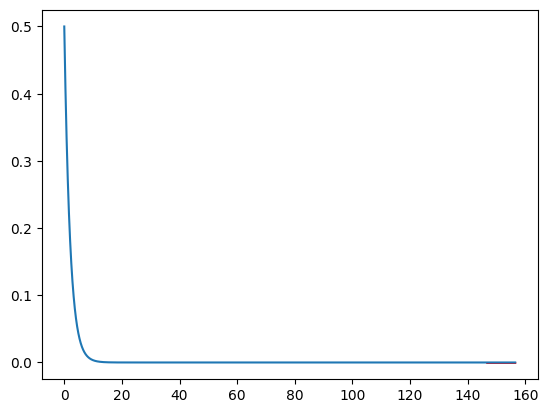

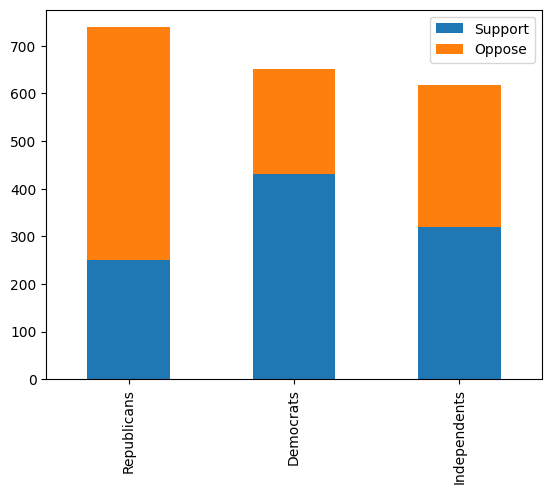

In [ ]:
import pandas as pd
O = pd.DataFrame({'Support':[250,431,320], 'Oppose':[489,220,298]},
                 index= ['Republicans','Democrats','Independents'])
ChiSqIndependence(O)

In [ ]:
O.iloc[:,0]/O.sum(axis=1)

Republicans     0.338295
Democrats       0.662058
Independents    0.517799
dtype: float64

         Upper Class  Middle Class  Low Class   Sum
Brand A          130           100         70   300
Brand B           30           400         70   500
Brand C           20            60         20   100
Brand D           20            40         40   100
4                200           600        200  1000
nr, nc =  4 3
Expected in cell E00 = 300*200/1000 = 60.000
Expected in cell E01 = 300*600/1000 = 180.000
Expected in the last cell = 100*200/1000 = 20.000
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(130-60.00)**2/60.00 +  ... + (40-20.00)**2/20.00 = 236.889
degree of freedom = df =(nr-1)(nc-1)= (4-1)(3-1) = 6
pval = 1 - chi2.cdf(X2,df) =  0.0 

From built in chisquare : X2 =  236.889   pval =  0.0
Expected: 
[[ 60. 180.  60.]
 [100. 300. 100.]
 [ 20.  60.  20.]
 [ 20.  60.  20.]]


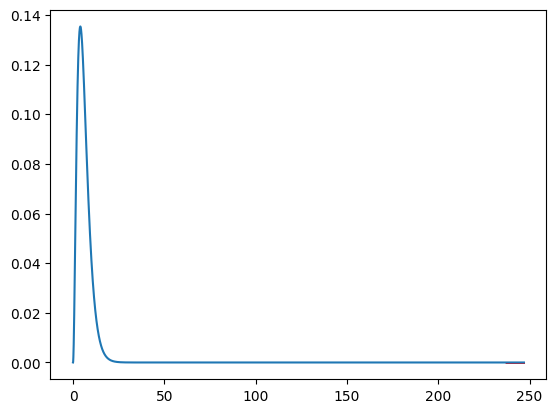

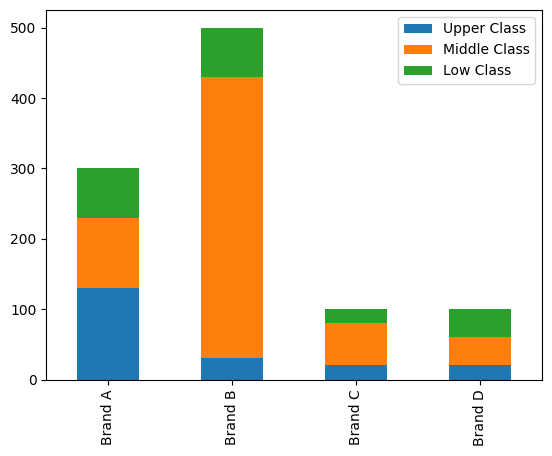

In [ ]:
import pandas as pd
O = pd.DataFrame({'Upper Class':[130,30,20,20], 'Middle Class':[100,400,60,40],
                  'Low Class':[70,70,20,40]},
                 index= ['Brand A','Brand B','Brand C','Brand D'])
ChiSqIndependence(O)

sex        female  male  Sum
substance                   
alcohol        36   141  177
cocaine        41   111  152
heroin         30    94  124
3             107   346  453
nr, nc =  3 2
Expected in cell E00 = 177*107/453 = 41.808
Expected in cell E01 = 177*346/453 = 135.192
Expected in the last cell = 124*346/453 = 94.711
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(36-41.81)**2/41.81 +  ... + (94-94.71)**2/94.71 = 2.026
degree of freedom = df =(nr-1)(nc-1)= (3-1)(2-1) = 2
pval = 1 - chi2.cdf(X2,df) =  0.3630623650067597 

From built in chisquare : X2 =  2.026   pval =  0.3630623650067597
Expected: 
[[ 41.80794702 135.19205298]
 [ 35.90286976 116.09713024]
 [ 29.28918322  94.71081678]]


<ipython-input-2-bf5f47ca46e8>:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[0],colsum[0],O.sum().sum(),E[0,0]))
<ipython-input-2-bf5f47ca46e8>:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[0],colsum[1],O.sum().sum(),E[0,1]))
<ipython-input-2-bf5f47ca46e8>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[nr-1],colsum[nc-1],O.sum().sum(),E[nr-1,nc-1]))


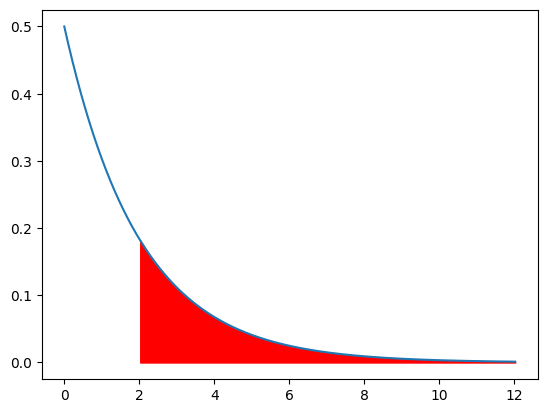

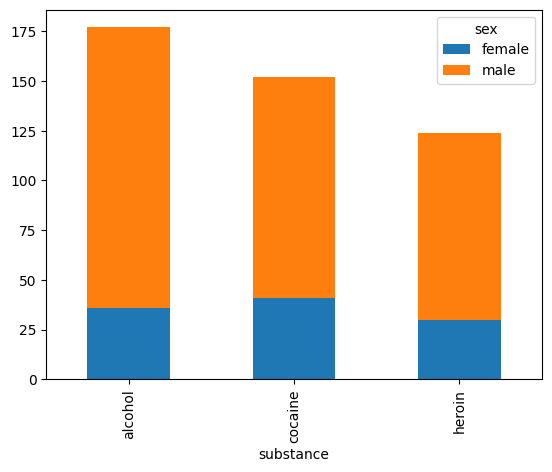

In [ ]:
import pandas as pd
url="https://raw.githubusercontent.com/leonkag/Statistics0/main/HELPrct.csv"
mydata = pd.read_csv(url)

O  = pd.crosstab(mydata.substance, mydata.sex, margins=False)
ChiSqIndependence(O)

In [ ]:
O.iloc[:,1]/O.sum(axis=1)

substance
alcohol    0.796610
cocaine    0.730263
heroin     0.758065
dtype: float64

        Barron's  Princeton  Sum
Passed        87         91  178
Failed        13         29   42
2            100        120  220
nr, nc =  2 2
Expected in cell E00 = 178*100/220 = 80.909
Expected in cell E01 = 178*120/220 = 97.091
Expected in the last cell = 42*120/220 = 22.909
Chi-Squared = sum( (O-E)**2/E )= sum( Residuals**2) = 
=(87-80.91)**2/80.91 +  ... + (29-22.91)**2/22.91 = 4.403
degree of freedom = df =(nr-1)(nc-1)= (2-1)(2-1) = 1
pval = 1 - chi2.cdf(X2,df) =  0.03586871998573926 

From built in chisquare : X2 =  4.403   pval =  0.03586871998573926
Expected: 
[[80.90909091 97.09090909]
 [19.09090909 22.90909091]]


<ipython-input-2-bf5f47ca46e8>:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[0],colsum[0],O.sum().sum(),E[0,0]))
<ipython-input-2-bf5f47ca46e8>:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[0],colsum[1],O.sum().sum(),E[0,1]))
<ipython-input-2-bf5f47ca46e8>:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .format(rowsum[nr-1],colsum[nc-1],O.sum().sum(),E[nr-1,nc-1]))


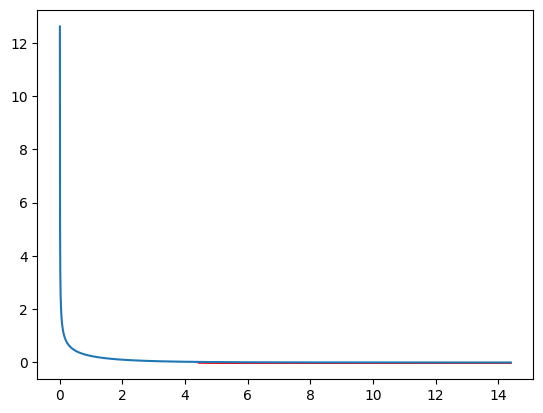

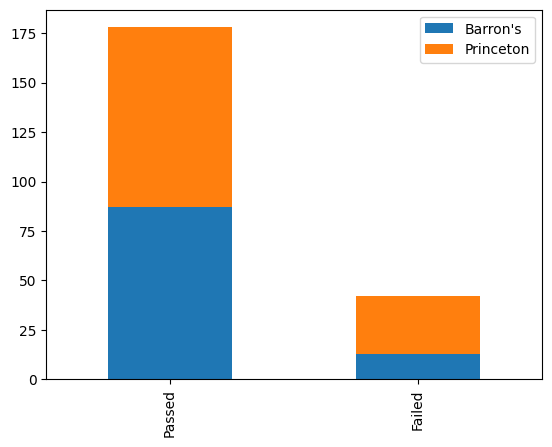

In [ ]:
import pandas as pd
O = pd.DataFrame({"Barron's":[87,13], 'Princeton':[91,29]},
                 index= ['Passed','Failed'])
ChiSqIndependence(O)